In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import tensorflow as tf

In [2]:
from tensorflow.keras.datasets import fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

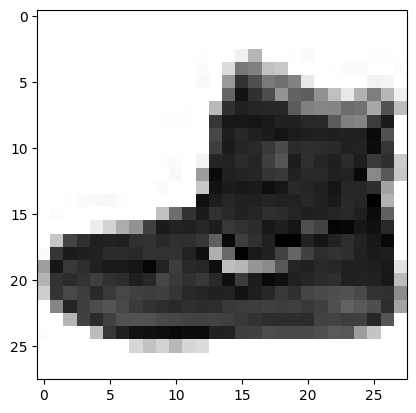

In [3]:
image = x_train[0]
plt.imshow(image, cmap=plt.cm.binary)
plt.show()

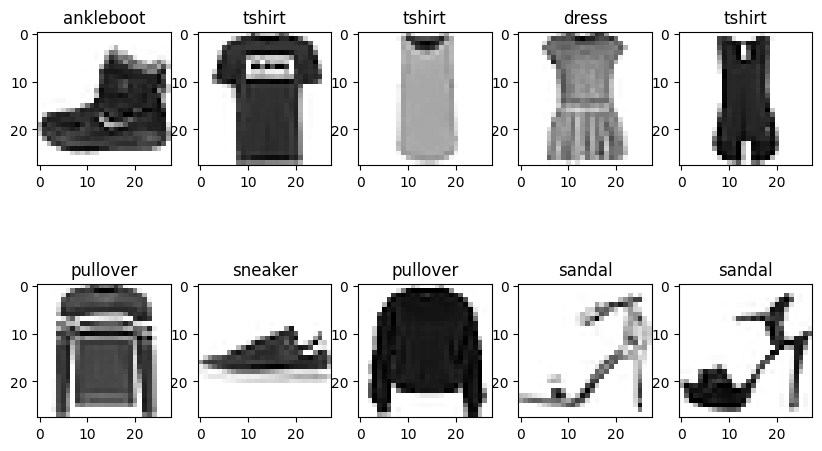

In [5]:
classes = np.array( ['tshirt', 'trouser', 'pullover', 'dress', 'coat', 'sandal', 'shirt', 'sneaker', 'bag', 'ankleboot'] )
classes

plt.figure(figsize=(10, 6))
for index in range(10):
    plt.subplot(2, 5, index+1)
    plt.imshow(x_train[index], cmap=plt.cm.binary)
    plt.title(f"{classes[ y_train[index] ]}")

plt.show()

In [7]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [11]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense, Flatten

model = Sequential([
    Input(shape=(28, 28)),
    Flatten(),
    Dense(128, activation='relu' ),
    Dense(10, activation='softmax') 
])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)                  │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
from tensorflow.keras.optimizers import SGD

optimizer = SGD(learning_rate=0.01) 

model.compile(
    optimizer=optimizer,
    metrics=['accuracy'],
    loss=tf.keras.losses.SparseCategoricalCrossentropy 
)

history = model.fit(x_train, y_train, epochs=10, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7447 - loss: 0.7946 - val_accuracy: 0.8095 - val_loss: 0.5726
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8190 - loss: 0.5373 - val_accuracy: 0.8276 - val_loss: 0.5049
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8329 - loss: 0.4893 - val_accuracy: 0.8369 - val_loss: 0.4759
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8408 - loss: 0.4632 - val_accuracy: 0.8362 - val_loss: 0.4600
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8458 - loss: 0.4445 - val_accuracy: 0.8388 - val_loss: 0.4495
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.8507 - loss: 0.4306 - val_accuracy: 0.8478 - val_loss: 0.4374
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8540 - loss: 0.4196 - val_accuracy: 0.8525 - val_loss: 0.4231
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8582 - loss: 0.4082

In [18]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)


index = model.predict( np.expand_dims(x_train[10], axis=0) )
print(f"Single => Predicted Class Is {classes[ np.argmax(index, axis=1) ]} ")

index = model.predict(x_train[:2])
print(f"Batched => Predicted Class Is {classes[ np.argmax(index, axis=1) ]} ")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8492 - loss: 0.4243
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step
Single => Predicted Class Is ['tshirt'] 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step
Batched => Predicted Class Is ['ankleboot' 'tshirt'] 


In [19]:
weights, bias = model.layers[1].get_weights()
weights, bias

(array([[-0.07348462,  0.04828988, -0.02805411, ..., -0.0658088 ,
         -0.00085792, -0.02658011],
        [ 0.04180254, -0.0573253 , -0.02268652, ..., -0.01329686,
         -0.08103566, -0.04760028],
        [ 0.01943582, -0.02412306, -0.07844722, ...,  0.05058438,
          0.00201987, -0.05451496],
        ...,
        [ 0.0410453 ,  0.05801114,  0.06095752, ...,  0.05177481,
          0.05636445,  0.07306878],
        [-0.00705094,  0.04369147, -0.0269667 , ..., -0.07651541,
         -0.02065383, -0.02051352],
        [ 0.00631885, -0.00726577, -0.07065939, ...,  0.04235866,
         -0.06719057,  0.01494506]], shape=(784, 128), dtype=float32),
 array([-1.20841749e-01,  3.53405178e-02,  1.87415302e-01, -1.33850304e-02,
         2.05966204e-01,  1.09479554e-01, -6.37358874e-02,  4.81605642e-02,
        -4.99848928e-03, -6.59687668e-02, -1.48473717e-02, -1.90374665e-02,
        -9.09658000e-02,  1.74050793e-01,  1.05902314e-01,  9.94873047e-02,
        -1.29188418e-01,  3.43296723

In [20]:
training_loss = history.history['loss'][-1]
training_accuracy = history.history['accuracy'][-1]

metrics = pd.DataFrame(
    data = [[training_loss, training_accuracy], [test_loss, test_accuracy]]
, columns=["Loss", "Accuracy"], index=["Training", "Testing"])

metrics

,Loss,Accuracy
Training,0.389670,0.864583
Testing,0.424278,0.849200
